In [1]:
#Set seed to use throughout
import numpy as np


SEED = 42
np.random.seed(42)

## Load Imputed Data

In [2]:
import pandas as pd

df = pd.read_csv("/Users/anna/Documents/01_university/01_academics/12_Winter2026/DATA 501/Project/FINAL_ANALYSIS/imputed_data_reduced/data_completed_imp1_with_weights.csv")
df2 = pd.read_csv("/Users/anna/Documents/01_university/01_academics/12_Winter2026/DATA 501/Project/FINAL_ANALYSIS/imputed_data_reduced/data_completed_imp2_with_weights.csv")
df3 = pd.read_csv("/Users/anna/Documents/01_university/01_academics/12_Winter2026/DATA 501/Project/FINAL_ANALYSIS/imputed_data_reduced/data_completed_imp3_with_weights.csv")
df4 = pd.read_csv("/Users/anna/Documents/01_university/01_academics/12_Winter2026/DATA 501/Project/FINAL_ANALYSIS/imputed_data_reduced/data_completed_imp4_with_weights.csv")
df5 = pd.read_csv("/Users/anna/Documents/01_university/01_academics/12_Winter2026/DATA 501/Project/FINAL_ANALYSIS/imputed_data_reduced/data_completed_imp5_with_weights.csv")

datasets = [df, df2, df3, df4, df5]


# Section 1: Testing Using One Imputed Dataset

## Data Exploration

In [44]:
df.head(10)

,PGM_P100,PGM_350,EDU_010,STULOANS,BEF_160,PAR1GRD,PAR2GRD,LFSTATP,WTPF
8,2,2,2,1,2,1,1,1,10.3937
11,2,2,1,1,6,1,1,1,89.2139
21,2,2,2,1,6,1,1,1,19.9220
24,2,2,2,2,3,2,2,1,10.4806
29,2,1,2,2,5,2,2,1,89.2139
31,2,1,2,2,5,1,1,1,11.0999
32,2,1,2,2,6,3,2,1,10.5646
36,1,1,2,1,2,2,2,1,58.5770
42,1,1,2,2,4,3,3,1,17.4488
44,2,1,2,2,6,2,2,1,10.4449


In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 1098 entries, 8 to 6745
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   PGM_P100  1098 non-null   int64  
 1   PGM_350   1098 non-null   int64  
 2   EDU_010   1098 non-null   int64  
 3   STULOANS  1098 non-null   int64  
 4   BEF_160   1098 non-null   int64  
 5   PAR1GRD   1098 non-null   int64  
 6   PAR2GRD   1098 non-null   int64  
 7   LFSTATP   1098 non-null   int64  
 8   WTPF      1098 non-null   float64
dtypes: float64(1), int64(8)
memory usage: 85.8 KB


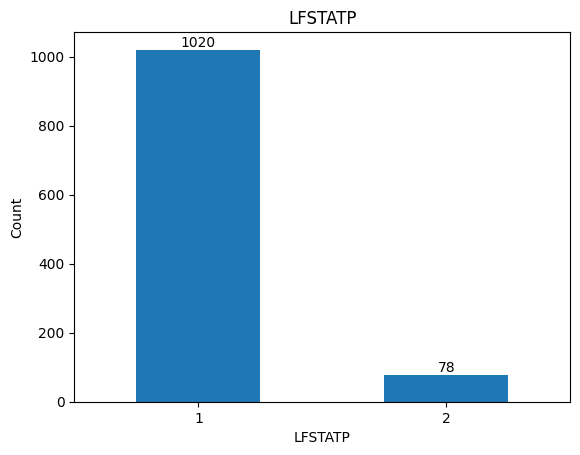

KeyError: 'PGMCIPAP'

In [46]:
import matplotlib.pyplot as plt  

#Inspect categorical variables (unweighted)
for col in ["LFSTATP", "PGMCIPAP"]:
    counts = df[col].value_counts()

    ax = counts.plot(kind="bar", title=col, rot=0)

    for i, v in enumerate(counts):
        ax.text(i, v, str(v), ha="center", va="bottom")

    plt.ylabel("Count")
    plt.show()

In [ ]:
filtered_datasets = []
columns_to_keep = ["PGM_P100", "PGM_350", "EDU_010", "STULOANS",
                    "BEF_160", "PAR1GRD", "PAR2GRD", "LFSTATP", "WTPF"]

# Loop through each dataset
for i, d in enumerate(datasets, start=1):
    #Filter df to only include LFSTATP = 1 or 2 (only keep employed or unemployed, filter out not in labour force and not states)
    d_filtered = d[d["LFSTATP"].isin([1, 2])].copy()
    

    """ 
    CHANGE WHICH FIELD OF STUDY TO FILTER BY HERE
    After changing the field of study, re-run notebook from the beginning, or do run all

    PGMCIPAP = 5 (Business, management and public administration)
    PGMCIPAP = 9 (Health and related Fields)
    PGMCIPAP = 4 (Social and Behavioural Sciences and Law)
    """
    d_filtered = d_filtered[d_filtered["PGMCIPAP"].isin([4])].copy()

    #Filter for the 6 narrowed down fields from LCA
    d_filtered = d_filtered[columns_to_keep]
    
    # Store filtered dataset
    filtered_datasets.append(d_filtered)
    
    # Print number of rows
    print(f"df{i} rows after filtering: {len(d_filtered)}")

# Optional: reassign back if you want to overwrite
df, df2, df3, df4, df5 = filtered_datasets
datasets = [df, df2, df3, df4, df5]

df1 rows after filtering: 1099
df2 rows after filtering: 1098
df3 rows after filtering: 1099
df4 rows after filtering: 1099
df5 rows after filtering: 1098


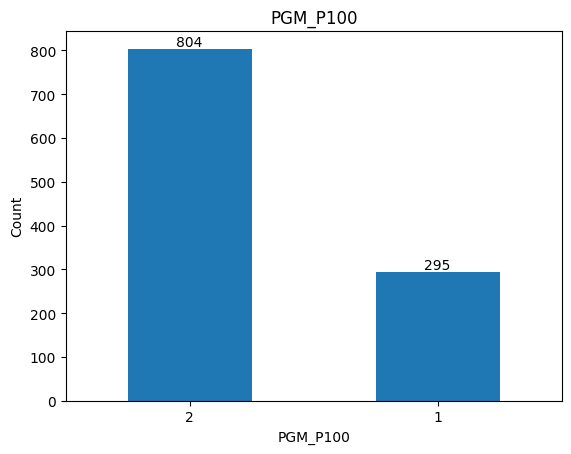

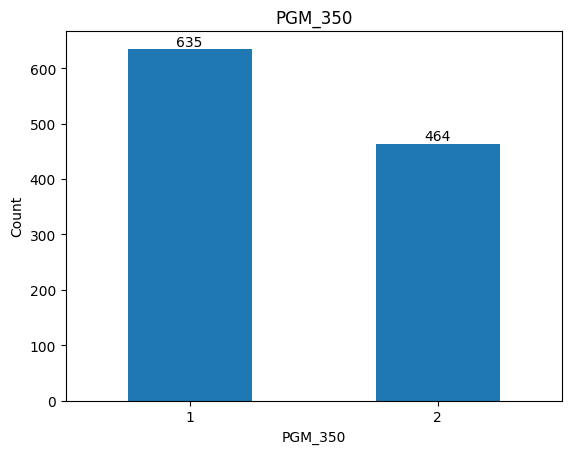

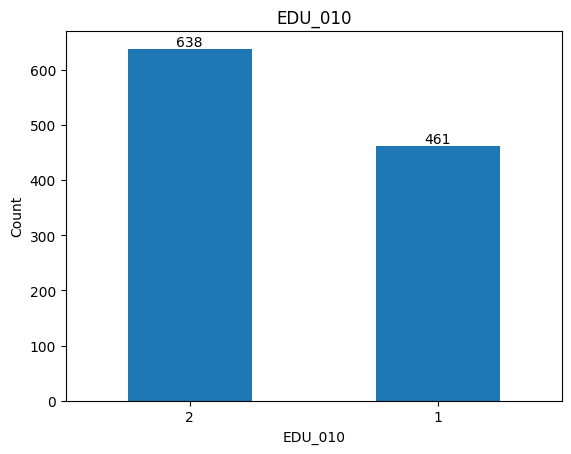

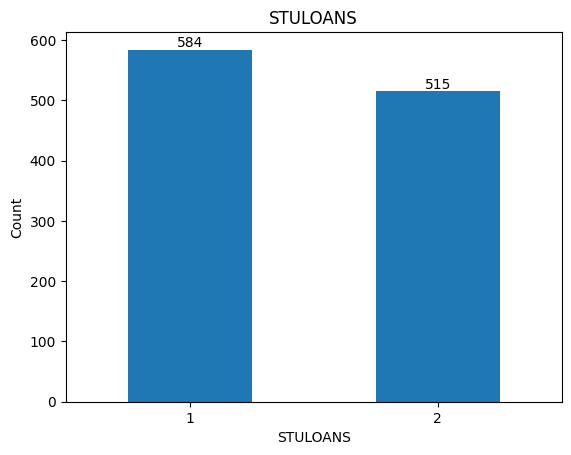

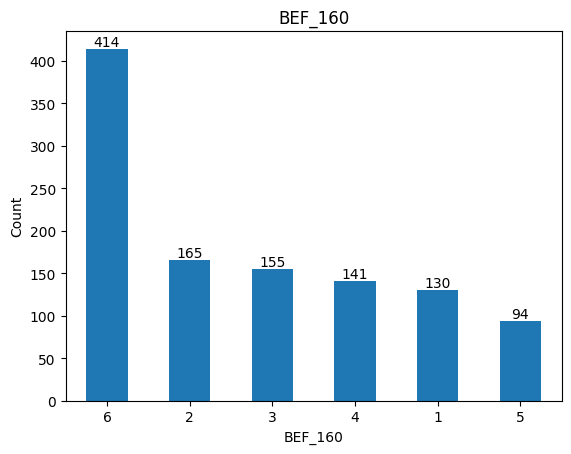

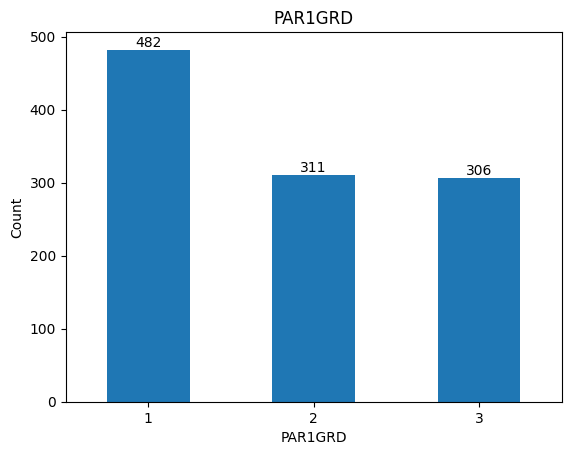

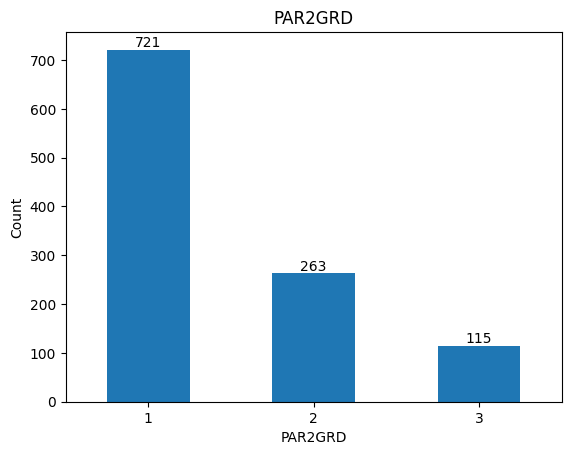

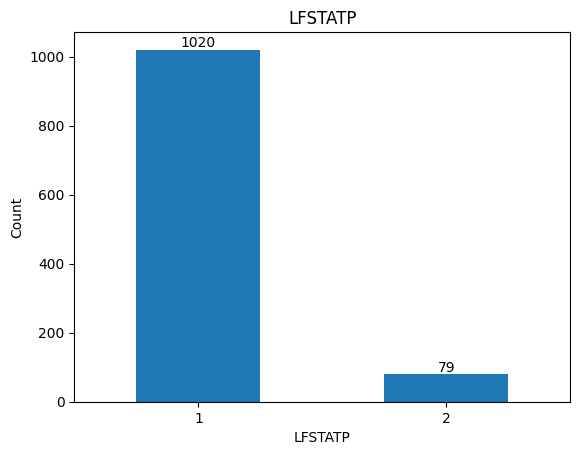

In [ ]:
import matplotlib.pyplot as plt  

#Inspect categorical variables (unweighted)
for col in df.drop(columns=["WTPF"]):
    counts = df[col].value_counts()

    ax = counts.plot(kind="bar", title=col, rot=0)

    for i, v in enumerate(counts):
        ax.text(i, v, str(v), ha="center", va="bottom")

    plt.ylabel("Count")
    plt.show()

In [ ]:

for d in datasets:

    # Unweighted counts and percentages
    counts = d["LFSTATP"].value_counts()
    percentages = d["LFSTATP"].value_counts(normalize=True) * 100

    # Weighted counts
    weighted_counts = d.groupby("LFSTATP")["WTPF"].sum()

    # Weighted percentages
    weighted_percentages = weighted_counts / weighted_counts.sum() * 100

    # Combine into a single dataframe
    summary = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
        "weighted_count": weighted_counts,
        "weighted_percentage": weighted_percentages
    })

    print(summary)

         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1         1020   92.811647      39242.4936            92.645525
2           79    7.188353       3115.1850             7.354475
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1         1020   92.896175      39291.1182            92.677753
2           78    7.103825       3104.2970             7.322247
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1         1021   92.902639      39252.8103            92.671131
2           78    7.097361       3104.2970             7.328869
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1         1021   92.902639      39303.1102            92.679824
2           78    7.097361       3104.29

In [ ]:
#Check for missing values

for d in datasets:
    missing_counts = d.isna().sum()
    print(missing_counts)

    missing_percent = d.isna().mean() * 100
    print(missing_percent)

PGM_P100    0
PGM_350     0
EDU_010     0
STULOANS    0
BEF_160     0
PAR1GRD     0
PAR2GRD     0
LFSTATP     0
WTPF        0
dtype: int64
PGM_P100    0.0
PGM_350     0.0
EDU_010     0.0
STULOANS    0.0
BEF_160     0.0
PAR1GRD     0.0
PAR2GRD     0.0
LFSTATP     0.0
WTPF        0.0
dtype: float64
PGM_P100    0
PGM_350     0
EDU_010     0
STULOANS    0
BEF_160     0
PAR1GRD     0
PAR2GRD     0
LFSTATP     0
WTPF        0
dtype: int64
PGM_P100    0.0
PGM_350     0.0
EDU_010     0.0
STULOANS    0.0
BEF_160     0.0
PAR1GRD     0.0
PAR2GRD     0.0
LFSTATP     0.0
WTPF        0.0
dtype: float64
PGM_P100    0
PGM_350     0
EDU_010     0
STULOANS    0
BEF_160     0
PAR1GRD     0
PAR2GRD     0
LFSTATP     0
WTPF        0
dtype: int64
PGM_P100    0.0
PGM_350     0.0
EDU_010     0.0
STULOANS    0.0
BEF_160     0.0
PAR1GRD     0.0
PAR2GRD     0.0
LFSTATP     0.0
WTPF        0.0
dtype: float64
PGM_P100    0
PGM_350     0
EDU_010     0
STULOANS    0
BEF_160     0
PAR1GRD     0
PAR2GRD     0
LFSTATP 

## Train-Test Split

In [ ]:
#Split to test and train datasets

from sklearn.model_selection import train_test_split

X = df.drop(["WTPF", "LFSTATP"], axis=1)
y = df["LFSTATP"]
weights = df["WTPF"]


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.3, #70 30 split
    random_state=SEED,
    stratify=y #stratifed
)

## Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_cols = X_train.columns.tolist()

# Get sorted unique values for each column
categories = [sorted(X_train[col].dropna().unique()) for col in categorical_cols]

preprocessing = Pipeline([
    ("onehot", OneHotEncoder(
        categories=categories,
        handle_unknown="ignore",
        sparse_output=False  # use sparse_output instead of sparse
    ))
])

In [ ]:
#fit and transformed the training data to the preprocessing pipeline to check if the output is as expected.
processed_train = preprocessing.fit_transform(X_train)
processed_train.shape

(769, 20)

In [ ]:
preprocessing.get_feature_names_out()

array(['PGM_P100_1', 'PGM_P100_2', 'PGM_350_1', 'PGM_350_2', 'EDU_010_1',
       'EDU_010_2', 'STULOANS_1', 'STULOANS_2', 'BEF_160_1', 'BEF_160_2',
       'BEF_160_3', 'BEF_160_4', 'BEF_160_5', 'BEF_160_6', 'PAR1GRD_1',
       'PAR1GRD_2', 'PAR1GRD_3', 'PAR2GRD_1', 'PAR2GRD_2', 'PAR2GRD_3'],
      dtype=object)

In [ ]:
processed_train_df = pd.DataFrame(
    processed_train,
    columns=preprocessing.get_feature_names_out(),
    index=X_train.index)

processed_train_df.head(10)

,PGM_P100_1,PGM_P100_2,PGM_350_1,PGM_350_2,EDU_010_1,EDU_010_2,STULOANS_1,STULOANS_2,BEF_160_1,BEF_160_2,BEF_160_3,BEF_160_4,BEF_160_5,BEF_160_6,PAR1GRD_1,PAR1GRD_2,PAR1GRD_3,PAR2GRD_1,PAR2GRD_2,PAR2GRD_3
1604,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4035,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4242,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2116,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5474,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
5458,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3567,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
144,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2756,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2884,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
processed_train_df.info()

<class 'pandas.DataFrame'>
Index: 769 entries, 1604 to 1763
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PGM_P100_1  769 non-null    float64
 1   PGM_P100_2  769 non-null    float64
 2   PGM_350_1   769 non-null    float64
 3   PGM_350_2   769 non-null    float64
 4   EDU_010_1   769 non-null    float64
 5   EDU_010_2   769 non-null    float64
 6   STULOANS_1  769 non-null    float64
 7   STULOANS_2  769 non-null    float64
 8   BEF_160_1   769 non-null    float64
 9   BEF_160_2   769 non-null    float64
 10  BEF_160_3   769 non-null    float64
 11  BEF_160_4   769 non-null    float64
 12  BEF_160_5   769 non-null    float64
 13  BEF_160_6   769 non-null    float64
 14  PAR1GRD_1   769 non-null    float64
 15  PAR1GRD_2   769 non-null    float64
 16  PAR1GRD_3   769 non-null    float64
 17  PAR2GRD_1   769 non-null    float64
 18  PAR2GRD_2   769 non-null    float64
 19  PAR2GRD_3   769 non-null    float64
dtype

## Model Creation/Training

### random_forest_pipeline

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

#Make and fit random forest pipeline (with no hyperparameters)
random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessing),          
    ("random_forest", RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED, oob_score=True, class_weight='balanced')) 
    #try version without class_weight=balanced
])

random_forest_pipeline.fit(X_train, y_train, random_forest__sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should 

In [ ]:
import pandas as pd

# Predict
y_train_pred = random_forest_pipeline.predict(X_train)
y_test_pred = random_forest_pipeline.predict(X_test)

# Function to create count + percentage table with weights
def count_percentage_table(values, weights=None, title=""):
    values = pd.Series(values)
    
    # Unweighted counts and percentages
    counts = values.value_counts()
    percentages = values.value_counts(normalize=True) * 100
    
    # Weighted counts and percentages
    if weights is not None:
        weights = pd.Series(weights, index=values.index)
        weighted_counts = values.groupby(values).apply(lambda x: weights[x.index].sum())
        weighted_percentages = weighted_counts / weighted_counts.sum() * 100
    else:
        weighted_counts = pd.Series([None]*len(counts), index=counts.index)
        weighted_percentages = pd.Series([None]*len(counts), index=counts.index)
    
    table = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
        "weighted_count": weighted_counts,
        "weighted_percentage": weighted_percentages
    }).sort_index()
    
    print(f"\n{title}")
    print(table)

# Table 1: Training true values
count_percentage_table(y_train, weights=w_train, title="Table 1: Training true values")

# Table 2: Training predictions
count_percentage_table(y_train_pred, weights=w_train, title="Table 2: Training predictions")

# Table 3: Test true values
count_percentage_table(y_test, weights=w_test, title="Table 3: Test true values")

# Table 4: Test predictions
count_percentage_table(y_test_pred, weights=w_test, title="Table 4: Test predictions")


Table 1: Training true values
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1          714   92.847854      26747.8460            92.545247
2           55    7.152146       2154.6065             7.454753

Table 2: Training predictions
   count  percentage  weighted_count  weighted_percentage
1    634   82.444733       2900.6997             89.20404
2    135   17.555267        351.0585             10.79596

Table 3: Test true values
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1          306   92.727273      12494.6476            92.860926
2           24    7.272727        960.5785             7.139074

Table 4: Test predictions
   count  percentage  weighted_count  weighted_percentage
1    284   86.060606        452.4894                100.0
2     46   13.939394          0.0000                  0.0


### best_random_forest_pipeline

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

scorer = make_scorer(recall_score, pos_label=2)  # set your positive class

param_grid = {
    "random_forest__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "random_forest__min_samples_leaf": [1,2,3,5,10,12,15,18,20],
    "random_forest__max_depth": [5, 10, 15, None]
}

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(
    random_forest_pipeline,
    param_grid=param_grid,
    scoring=scorer,
    cv=10,
    n_jobs=-1
)

grid_search.fit(X_train, y_train, random_forest__sample_weight=w_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'random_forest__max_depth': [5, 10, ...], 'random_forest__max_features': ['sqrt', 'log2', ...], 'random_forest__min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(r..., pos_label=2)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [ ]:
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

Best hyperparameters: {'random_forest__max_depth': 15, 'random_forest__max_features': 'sqrt', 'random_forest__min_samples_leaf': 1}
Best cross-validated accuracy: 0.2566666666666667


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

#Make and fit random forest pipeline (with hyperparameters)
best_random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessing),          
    ("random_forest", RandomForestClassifier(
        n_estimators=100, 
        n_jobs=-1, 
        random_state=SEED, 
        oob_score=True,
        max_features=grid_search.best_params_["random_forest__max_features"],
        min_samples_leaf=grid_search.best_params_["random_forest__min_samples_leaf"],
        max_depth=grid_search.best_params_["random_forest__max_depth"],
        class_weight="balanced"
        ))
])

best_random_forest_pipeline.fit(X_train, y_train, random_forest__sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should 

In [ ]:
import pandas as pd

# Predict
y_train_pred = best_random_forest_pipeline.predict(X_train)
y_test_pred = best_random_forest_pipeline.predict(X_test)

# Function to create count + percentage table with weights
def count_percentage_table(values, weights=None, title=""):
    values = pd.Series(values)
    
    # Unweighted counts and percentages
    counts = values.value_counts()
    percentages = values.value_counts(normalize=True) * 100
    
    # Weighted counts and percentages
    if weights is not None:
        weights = pd.Series(weights, index=values.index)
        weighted_counts = values.groupby(values).apply(lambda x: weights[x.index].sum())
        weighted_percentages = weighted_counts / weighted_counts.sum() * 100
    else:
        weighted_counts = pd.Series([None]*len(counts), index=counts.index)
        weighted_percentages = pd.Series([None]*len(counts), index=counts.index)
    
    table = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
        "weighted_count": weighted_counts,
        "weighted_percentage": weighted_percentages
    }).sort_index()
    
    print(f"\n{title}")
    print(table)

# Table 1: Training true values
count_percentage_table(y_train, weights=w_train, title="Table 1: Training true values")

# Table 2: Training predictions
count_percentage_table(y_train_pred, weights=w_train, title="Table 2: Training predictions")

# Table 3: Test true values
count_percentage_table(y_test, weights=w_test, title="Table 3: Test true values")

# Table 4: Test predictions
count_percentage_table(y_test_pred, weights=w_test, title="Table 4: Test predictions")


Table 1: Training true values
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1          714   92.847854      26747.8460            92.545247
2           55    7.152146       2154.6065             7.454753

Table 2: Training predictions
   count  percentage  weighted_count  weighted_percentage
1    634   82.444733       2900.6997             89.20404
2    135   17.555267        351.0585             10.79596

Table 3: Test true values
         count  percentage  weighted_count  weighted_percentage
LFSTATP                                                        
1          306   92.727273      12494.6476            92.860926
2           24    7.272727        960.5785             7.139074

Table 4: Test predictions
   count  percentage  weighted_count  weighted_percentage
1    284   86.060606        452.4894                100.0
2     46   13.939394          0.0000                  0.0


## Model Evaluation

In [ ]:
# ===============================
# EVALUATION FUNCTION
# ===============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def evaluate_func(model, X_train, X_test, y_train, y_test, w_train, w_test, positive_class):
    #Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities
    y_train_prob_matrix = model.predict_proba(X_train)
    y_test_prob_matrix = model.predict_proba(X_test)
    
    # Find correct column for positive class
    classes = model.named_steps[list(model.named_steps.keys())[-1]].classes_
    idx = np.where(classes == positive_class)[0][0]
    
    y_train_prob = y_train_prob_matrix[:, idx]
    y_test_prob = y_test_prob_matrix[:, idx]

    # Encode positive class as 1, negative as 0
    y_train_bin = (y_train == positive_class).astype(int)
    y_test_bin = (y_test == positive_class).astype(int)

    print("TRAINING METRICS")
    print("Accuracy :", accuracy_score(y_train, y_train_pred, sample_weight=w_train))
    print("Precision:", precision_score(y_train, y_train_pred, pos_label=positive_class, sample_weight=w_train))
    print("Recall   :", recall_score(y_train, y_train_pred, pos_label=positive_class, sample_weight=w_train))
    print("F1-score :", f1_score(y_train, y_train_pred, pos_label=positive_class, sample_weight=w_train))
    print("AUC      :", roc_auc_score(y_train_bin, y_train_prob, sample_weight=w_train))

    
    print("\nTEST METRICS")
    print("Accuracy :", accuracy_score(y_test, y_test_pred, sample_weight=w_test))
    print("Precision:", precision_score(y_test, y_test_pred, pos_label=positive_class, sample_weight=w_test))
    print("Recall   :", recall_score(y_test, y_test_pred, pos_label=positive_class, sample_weight=w_test))
    print("F1-score :", f1_score(y_test, y_test_pred, pos_label=positive_class, sample_weight=w_test))
    print("AUC      :", roc_auc_score(y_test_bin, y_test_prob, sample_weight=w_test))

### random_forest_pipeline

In [ ]:
rf_model = random_forest_pipeline.named_steps["random_forest"]
print("OOB Accuracy:", rf_model.oob_score_)

OOB Accuracy: 0.8244473342002601


In [ ]:
from sklearn.metrics import confusion_matrix
# Predict on test set
y_train_pred = random_forest_pipeline.predict(X_train)

# Confusion matrix
cm = confusion_matrix(y_train, y_train_pred, labels=[1, 2])

# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=["Actual 1", "Actual 2"], columns=["Predicted 1", "Predicted 2"])
print(cm_df)

          Predicted 1  Predicted 2
Actual 1          629           85
Actual 2            5           50


In [ ]:
from sklearn.metrics import confusion_matrix
# Predict on test set
y_test_pred = random_forest_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=["Actual 1", "Actual 2"], columns=["Predicted 1", "Predicted 2"])
print(cm_df)

          Predicted 1  Predicted 2
Actual 1          262           44
Actual 2           22            2


In [ ]:
print("Positive Class = 2 (unemployed)\n")
evaluate_func(random_forest_pipeline, X_train, X_test, y_train, y_test, w_train, w_test, 2)

Positive Class = 2 (unemployed)

TRAINING METRICS
Accuracy : 0.8994511175132976
Precision: 0.42388040701334023
Recall   : 0.971134822066117
F1-score : 0.5901656341255139
AUC      : 0.973079458169327

TEST METRICS
Accuracy : 0.7865947789610166
Precision: 0.05587495309676624
Recall   : 0.12513324002150789
F1-score : 0.07725411537012099
AUC      : 0.48866608450561533


In [ ]:
print("Positive Class = 1 (employed)\n")
evaluate_func(random_forest_pipeline, X_train, X_test, y_train, y_test, w_train, w_test, 1)

Positive Class = 1 (employed)

TRAINING METRICS
Accuracy : 0.8994511175132976
Precision: 0.9974049578123463
Recall   : 0.8936768142002912
F1-score : 0.9426960783580086
AUC      : 0.973079458169327

TEST METRICS
Accuracy : 0.7865947789610166
Precision: 0.9256564884155716
Recall   : 0.8374474122823603
F1-score : 0.8793453755948648
AUC      : 0.4886660845056161


0


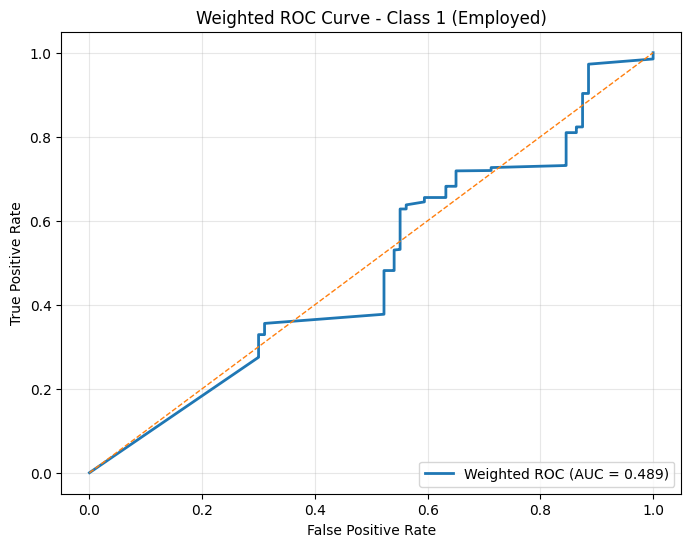

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
y_prob_matrix = random_forest_pipeline.predict_proba(X_test)

# Get column index for class 1
classes = random_forest_pipeline.named_steps['random_forest'].classes_
class1_index = np.where(classes == 1)[0][0]
print(class1_index)

# Probabilities for class 1
y_prob_class1 = y_prob_matrix[:, class1_index]

# Weighted ROC
fpr1, tpr1, thresholds1 = roc_curve(
    y_test,
    y_prob_class1,
    pos_label=1,
    sample_weight=w_test   
)

# AUC (consistent with weighted ROC)
roc_auc1 = auc(fpr1, tpr1)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, lw=2, label=f"Weighted ROC (AUC = {roc_auc1:.3f})")
plt.plot([0,1], [0,1], lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Weighted ROC Curve - Class 1 (Employed)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### best_random_forest_pipeline

In [ ]:
from sklearn.metrics import confusion_matrix
# Predict on test set
y_train_pred = best_random_forest_pipeline.predict(X_train)

# Confusion matrix
cm = confusion_matrix(y_train, y_train_pred, labels=[1, 2])

# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=["Actual 1", "Actual 2"], columns=["Predicted 1", "Predicted 2"])
print(cm_df)

          Predicted 1  Predicted 2
Actual 1          629           85
Actual 2            5           50


In [ ]:
from sklearn.metrics import confusion_matrix
# Predict on test set
y_test_pred = best_random_forest_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=["Actual 1", "Actual 2"], columns=["Predicted 1", "Predicted 2"])
print(cm_df)

          Predicted 1  Predicted 2
Actual 1          262           44
Actual 2           22            2


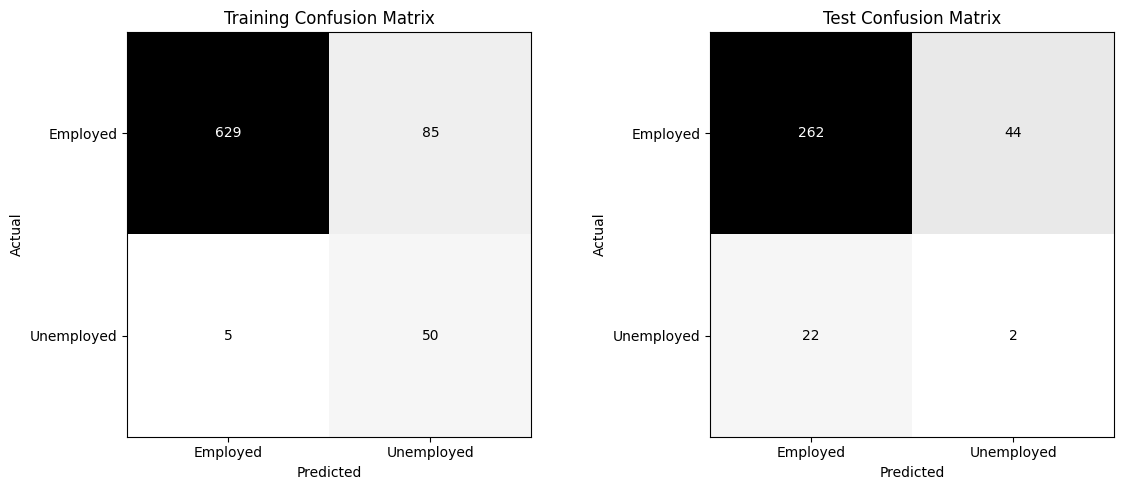

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_train_pred = best_random_forest_pipeline.predict(X_train)
y_test_pred = best_random_forest_pipeline.predict(X_test)

# Define label mapping
labels = [1, 2]
display_labels = ["Employed", "Unemployed"]

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels)
disp_train.plot(ax=axes[0], cmap='Greys', colorbar=False, values_format='d')
axes[0].set_title("Training Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Test
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=display_labels)
disp_test.plot(ax=axes[1], cmap='Greys', colorbar=False, values_format='d')
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
print("Positive Class = 2 (unemployed)\n")
evaluate_func(best_random_forest_pipeline, X_train, X_test, y_train, y_test, w_train, w_test, 2)

Positive Class = 2 (unemployed)

TRAINING METRICS
Accuracy : 0.8994511175132976
Precision: 0.42388040701334023
Recall   : 0.971134822066117
F1-score : 0.5901656341255139
AUC      : 0.973079458169327

TEST METRICS
Accuracy : 0.7865947789610166
Precision: 0.05587495309676624
Recall   : 0.12513324002150789
F1-score : 0.07725411537012099
AUC      : 0.48866608450561533


In [ ]:
print("Positive Class = 1 (employed)\n")
evaluate_func(best_random_forest_pipeline, X_train, X_test, y_train, y_test, w_train, w_test, 1)

Positive Class = 1 (employed)

TRAINING METRICS
Accuracy : 0.8994511175132976
Precision: 0.9974049578123463
Recall   : 0.8936768142002912
F1-score : 0.9426960783580086
AUC      : 0.973079458169327

TEST METRICS
Accuracy : 0.7865947789610166
Precision: 0.9256564884155716
Recall   : 0.8374474122823603
F1-score : 0.8793453755948648
AUC      : 0.4886660845056161


[1 2]


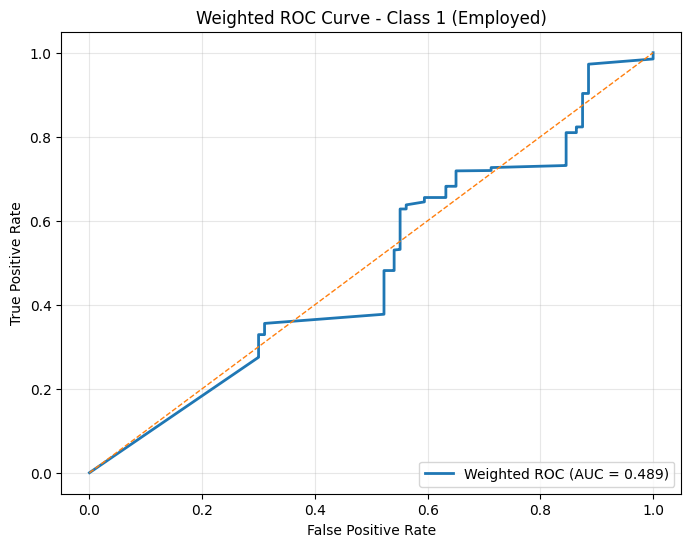

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
y_prob_matrix = best_random_forest_pipeline.predict_proba(X_test)

# Get column index for class 1
classes = best_random_forest_pipeline.named_steps['random_forest'].classes_
print(classes)
class1_index = np.where(classes == 1)[0][0]

# Probabilities for class 1
y_prob_class1 = y_prob_matrix[:, class1_index]

# Weighted ROC
fpr1, tpr1, thresholds1 = roc_curve(
    y_test,
    y_prob_class1,
    pos_label=1,
    sample_weight=w_test  
)

# AUC (consistent with weighted ROC)
roc_auc1 = auc(fpr1, tpr1)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, lw=2, label=f"Weighted ROC (AUC = {roc_auc1:.3f})")
plt.plot([0,1], [0,1], lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Weighted ROC Curve - Class 1 (Employed)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

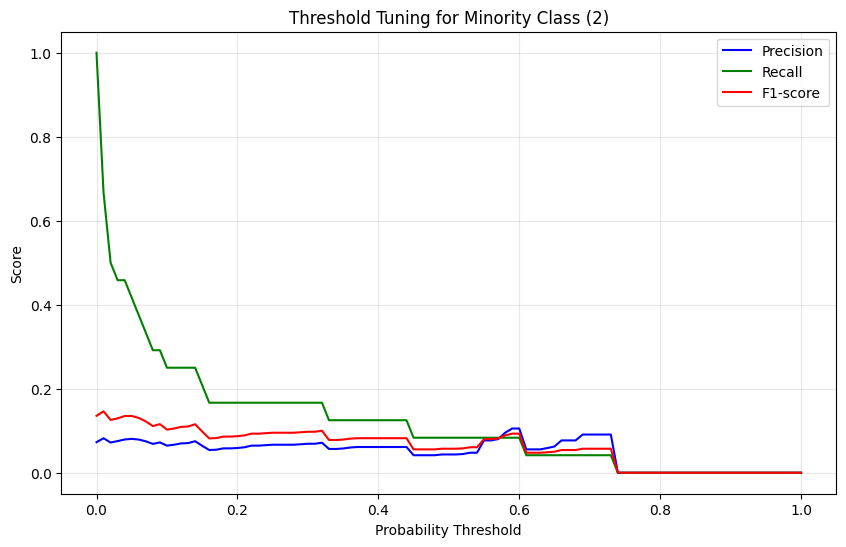

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# Predict probabilities for the positive (minority) class
y_prob = best_random_forest_pipeline.predict_proba(X_test)[:, 1]  # 1 = minority class

# Define thresholds
thresholds = np.linspace(0, 1, 101)

# Store metrics
precision_list, recall_list, f1_list = [], [], []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    y_true_binary = (y_test == 2).astype(int)  # minority = 1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_binary, y_pred, average='binary', zero_division=0
    )
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, precision_list, label='Precision', color='blue')
plt.plot(thresholds, recall_list, label='Recall', color='green')
plt.plot(thresholds, f1_list, label='F1-score', color='red')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Minority Class (2)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Feature Importance

### Method 1: MDI (Meand Decrease in Impurity)

In [ ]:
#Running feature imporance using mean decrease in impurity
rf_model = best_random_forest_pipeline.named_steps["random_forest"]
feature_names = best_random_forest_pipeline.named_steps["preprocessing"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_decrease_in_impurity": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(by="mean_decrease_in_impurity", ascending=False)

In [ ]:
#Sort decending
importance_df.sort_values(by="mean_decrease_in_impurity", ascending=False)

,feature,mean_decrease_in_impurity
13,BEF_160_6,0.078162
16,PAR1GRD_3,0.077854
8,BEF_160_1,0.069856
9,BEF_160_2,0.059372
2,PGM_350_1,0.053955
3,PGM_350_2,0.052941
17,PAR2GRD_1,0.052882
6,STULOANS_1,0.052402
5,EDU_010_2,0.052389
4,EDU_010_1,0.050290


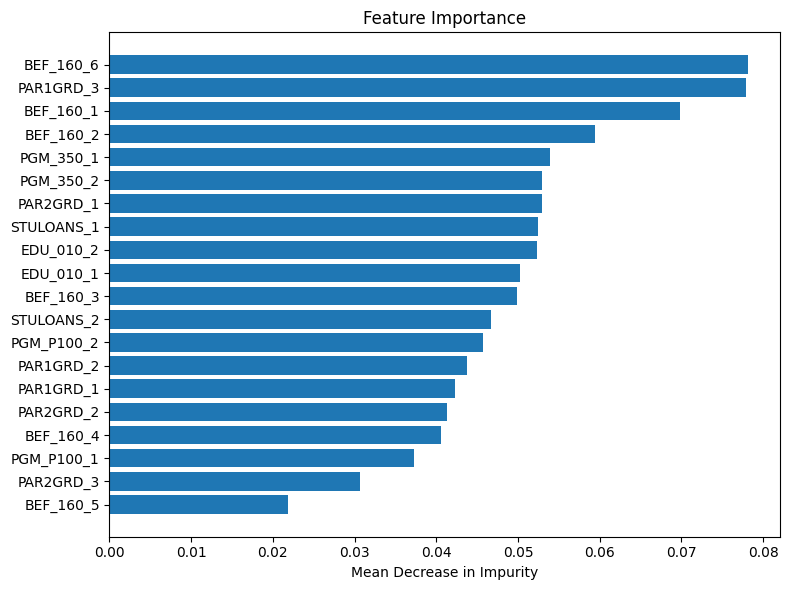

In [ ]:
import matplotlib.pyplot as plt

top15 = importance_df

plt.figure(figsize=(8, 6))
plt.barh(top15["feature"], top15["mean_decrease_in_impurity"])
plt.xlabel("Mean Decrease in Impurity")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Method 2: Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance

#Preprocess X_test to work with calculating permutation importance
X_test_processed = best_random_forest_pipeline.named_steps["preprocessing"].transform(X_test)
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

result = permutation_importance(
    best_random_forest_pipeline.named_steps["random_forest"],
    X_test_dense,
    y_test,
    n_repeats=20,
    random_state=SEED,
    n_jobs=-1
)

forest_importances_permutation = pd.Series(result.importances_mean, index=feature_names)

In [ ]:
forest_importances_permutation.sort_values(ascending=False)

PAR2GRD_3    -0.006970
BEF_160_4    -0.011970
BEF_160_5    -0.013333
BEF_160_1    -0.013485
BEF_160_3    -0.013485
BEF_160_2    -0.026970
PAR2GRD_2    -0.029697
PAR1GRD_2    -0.031970
PAR2GRD_1    -0.032424
PGM_P100_1   -0.032727
PGM_P100_2   -0.033788
EDU_010_1    -0.040000
EDU_010_2    -0.040152
PAR1GRD_3    -0.040909
PAR1GRD_1    -0.053485
BEF_160_6    -0.058485
PGM_350_1    -0.059242
PGM_350_2    -0.061212
STULOANS_2   -0.061970
STULOANS_1   -0.063939
dtype: float64

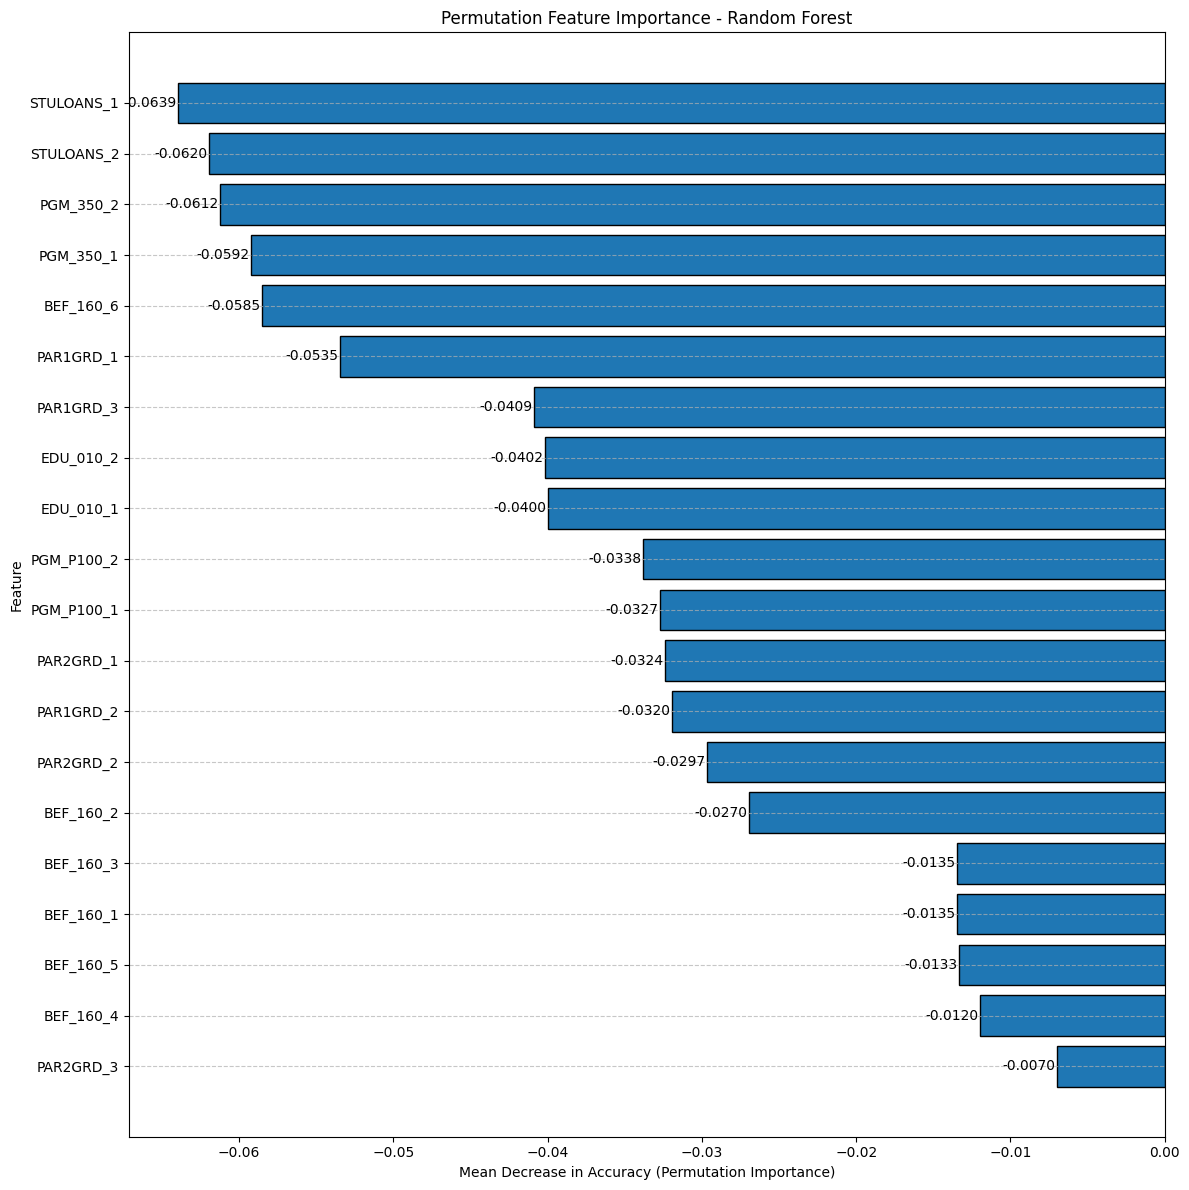

In [ ]:
import matplotlib.pyplot as plt

# Sort features for plotting
forest_importances_permutation_sorted = forest_importances_permutation.sort_values(ascending=False).head(20)

plt.figure(figsize=(12,12))
bars = plt.barh(
    forest_importances_permutation_sorted.index,
    forest_importances_permutation_sorted.values,
    edgecolor='black'
)

plt.xlabel("Mean Decrease in Accuracy (Permutation Importance)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Random Forest")

# Horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels, outside bars regardless of sign
ax = plt.gca()
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if width >= 0:
        x_text = width + 0.0001  # positive: place to the right
        ha = 'left'
    else:
        x_text = width - 0.0001  # negative: place to the left
        ha = 'right'
    ax.text(
        x=x_text,
        y=y,
        s=f"{width:.4f}",
        va='center',
        ha=ha,
        clip_on=True
    )

plt.tight_layout()
plt.show()

# Section 2: Using 5 Imputed Datasets


================ DATASET 1 ================

Best hyperparameters: {'random_forest__max_depth': 15, 'random_forest__max_features': 'sqrt', 'random_forest__min_samples_leaf': 1}
Best cross-validated accuracy: 0.2566666666666667

Confusion Matrix (Train):
          Predicted 1  Predicted 2
Actual 1          629           85
Actual 2            5           50
Confusion Matrix (Test):
          Predicted 1  Predicted 2
Actual 1          262           44
Actual 2           22            2

Positive Class = 2 (unemployed)
TRAINING METRICS
Accuracy : 0.8994511175132976
Precision: 0.42388040701334023
Recall   : 0.971134822066117
F1-score : 0.5901656341255139
AUC      : 0.973079458169327

TEST METRICS
Accuracy : 0.7865947789610166
Precision: 0.05587495309676624
Recall   : 0.12513324002150789
F1-score : 0.07725411537012099
AUC      : 0.48866608450561533

Positive Class = 1 (employed)
TRAINING METRICS
Accuracy : 0.8994511175132976
Precision: 0.9974049578123463
Recall   : 0.8936768142002912
F1-sc

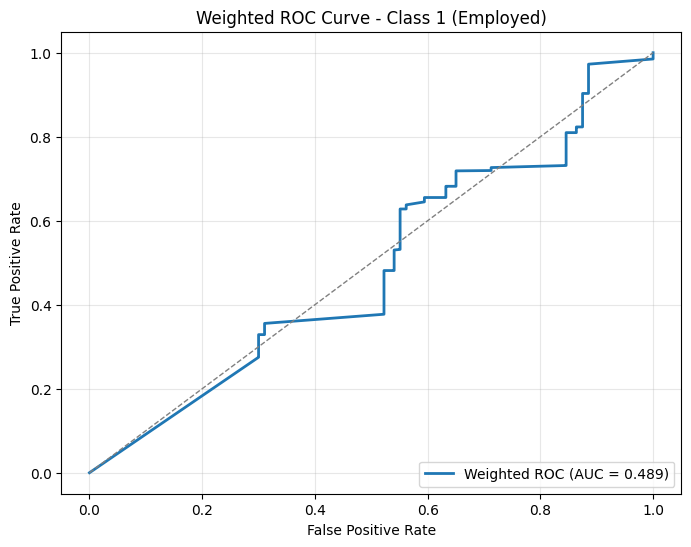


Permutation Importances:
PAR2GRD_3    -0.006970
BEF_160_4    -0.011970
BEF_160_5    -0.013333
BEF_160_1    -0.013485
BEF_160_3    -0.013485
BEF_160_2    -0.026970
PAR2GRD_2    -0.029697
PAR1GRD_2    -0.031970
PAR2GRD_1    -0.032424
PGM_P100_1   -0.032727
PGM_P100_2   -0.033788
EDU_010_1    -0.040000
EDU_010_2    -0.040152
PAR1GRD_3    -0.040909
PAR1GRD_1    -0.053485
BEF_160_6    -0.058485
PGM_350_1    -0.059242
PGM_350_2    -0.061212
STULOANS_2   -0.061970
STULOANS_1   -0.063939
dtype: float64

================ DATASET 2 ================

Best hyperparameters: {'random_forest__max_depth': 10, 'random_forest__max_features': 0.7, 'random_forest__min_samples_leaf': 10}
Best cross-validated accuracy: 0.3066666666666667

Confusion Matrix (Train):
          Predicted 1  Predicted 2
Actual 1          633           80
Actual 2           26           29
Confusion Matrix (Test):
          Predicted 1  Predicted 2
Actual 1          276           31
Actual 2           19            4

Positive C

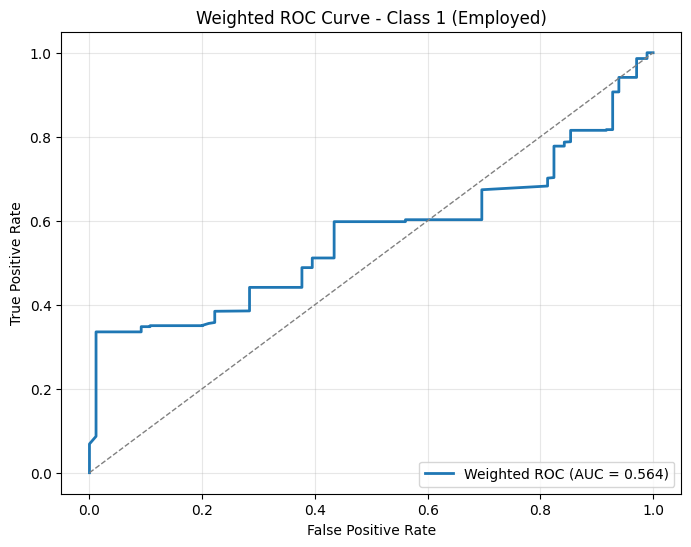


Permutation Importances:
PAR1GRD_1     0.012273
PAR1GRD_2     0.003939
PAR2GRD_3     0.001667
PGM_P100_2    0.001364
PAR2GRD_1     0.000152
PAR2GRD_2    -0.000303
BEF_160_3    -0.000303
EDU_010_2    -0.000606
PGM_P100_1   -0.000606
BEF_160_5    -0.001970
EDU_010_1    -0.002879
STULOANS_2   -0.003788
BEF_160_1    -0.003788
STULOANS_1   -0.003788
BEF_160_4    -0.004242
PGM_350_2    -0.004697
PGM_350_1    -0.005152
BEF_160_2    -0.006970
PAR1GRD_3    -0.007273
BEF_160_6    -0.026061
dtype: float64

================ DATASET 3 ================

Best hyperparameters: {'random_forest__max_depth': 10, 'random_forest__max_features': 0.5, 'random_forest__min_samples_leaf': 1}
Best cross-validated accuracy: 0.26

Confusion Matrix (Train):
          Predicted 1  Predicted 2
Actual 1          650           64
Actual 2            7           48
Confusion Matrix (Test):
          Predicted 1  Predicted 2
Actual 1          267           40
Actual 2           20            3

Positive Class = 2 (unemp

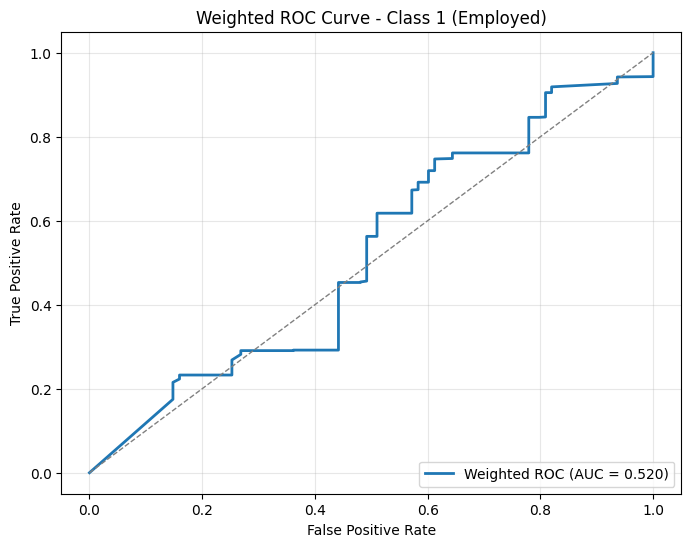


Permutation Importances:
BEF_160_4    -0.006364
PAR2GRD_3    -0.009394
BEF_160_5    -0.011061
BEF_160_3    -0.017424
BEF_160_1    -0.019394
PAR1GRD_3    -0.019848
PAR2GRD_2    -0.022727
PAR1GRD_2    -0.025303
PAR2GRD_1    -0.027121
EDU_010_1    -0.030303
PGM_P100_1   -0.030909
BEF_160_2    -0.033939
PGM_P100_2   -0.035000
PGM_350_1    -0.037121
PGM_350_2    -0.037424
PAR1GRD_1    -0.038939
EDU_010_2    -0.041667
STULOANS_2   -0.041970
STULOANS_1   -0.047879
BEF_160_6    -0.053030
dtype: float64

================ DATASET 4 ================

Best hyperparameters: {'random_forest__max_depth': 10, 'random_forest__max_features': 0.7, 'random_forest__min_samples_leaf': 2}
Best cross-validated accuracy: 0.2766666666666667

Confusion Matrix (Train):
          Predicted 1  Predicted 2
Actual 1          638           76
Actual 2            8           47
Confusion Matrix (Test):
          Predicted 1  Predicted 2
Actual 1          265           42
Actual 2           21            2

Positive Cl

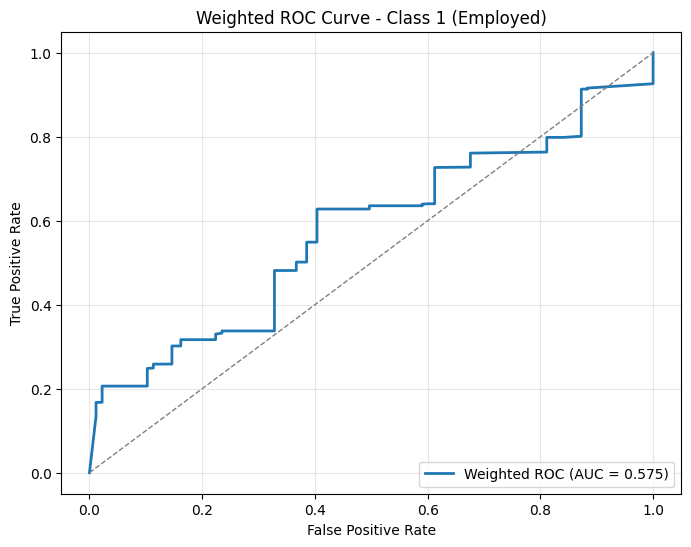


Permutation Importances:
PAR2GRD_3    -0.005758
BEF_160_5    -0.007121
BEF_160_1    -0.011667
PGM_P100_1   -0.011970
BEF_160_4    -0.012576
PGM_P100_2   -0.016515
BEF_160_3    -0.016667
PAR2GRD_2    -0.022879
BEF_160_2    -0.024242
PAR1GRD_2    -0.025152
PAR1GRD_3    -0.030606
EDU_010_1    -0.031970
EDU_010_2    -0.033333
PAR2GRD_1    -0.033636
PAR1GRD_1    -0.036364
PGM_350_2    -0.042576
STULOANS_1   -0.045455
STULOANS_2   -0.046818
PGM_350_1    -0.048788
BEF_160_6    -0.052727
dtype: float64

================ DATASET 5 ================

Best hyperparameters: {'random_forest__max_depth': 15, 'random_forest__max_features': 'sqrt', 'random_forest__min_samples_leaf': 1}
Best cross-validated accuracy: 0.26666666666666666

Confusion Matrix (Train):
          Predicted 1  Predicted 2
Actual 1          637           76
Actual 2            7           48
Confusion Matrix (Test):
          Predicted 1  Predicted 2
Actual 1          267           40
Actual 2           21            2

Positiv

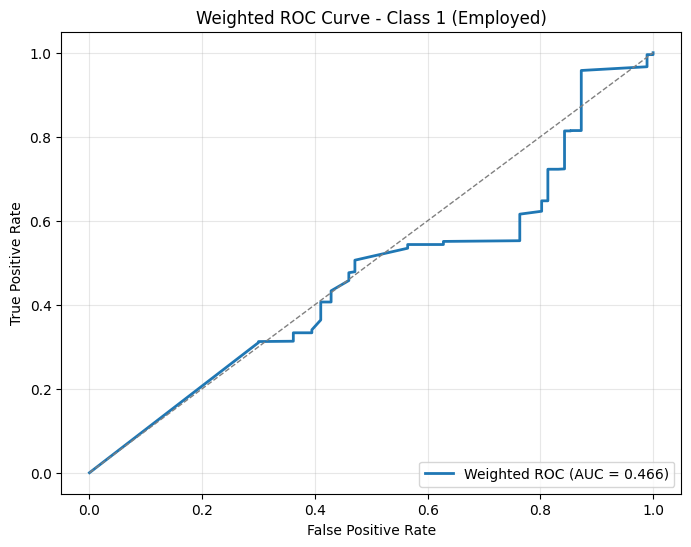


Permutation Importances:
PAR2GRD_3    -0.005152
BEF_160_5    -0.013182
BEF_160_4    -0.016970
BEF_160_1    -0.018788
BEF_160_3    -0.020909
PGM_P100_2   -0.023636
PGM_P100_1   -0.023636
BEF_160_2    -0.026061
PAR2GRD_2    -0.026818
PAR1GRD_2    -0.031970
PAR1GRD_3    -0.032727
PAR2GRD_1    -0.033788
EDU_010_2    -0.043333
EDU_010_1    -0.046970
PAR1GRD_1    -0.047121
BEF_160_6    -0.054848
PGM_350_1    -0.056212
STULOANS_1   -0.056818
PGM_350_2    -0.057879
STULOANS_2   -0.058182
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

SEED = 42




# STORAGE
metrics_list = []
conf_matrices = []
roc_data = []
perm_importances_list = []

# LOOP
for i, df in enumerate(datasets):
    print(f"\n================ DATASET {i+1} ================")

    # -----------------------------
    # TEST-TRAIN SPLIT
    # -----------------------------
    X = df.drop(["WTPF", "LFSTATP"], axis=1)
    y = df["LFSTATP"]
    weights = df["WTPF"]


    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, weights,
        test_size=0.3, #70 30 split
        random_state=SEED,
        stratify=y #stratifed
    )


    # -----------------------------
    # GRID SEARCH
    # -----------------------------
    rf_pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("random_forest", RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED, oob_score=True, class_weight='balanced')) 
    ])


    scorer = make_scorer(recall_score, pos_label=2)  # set your positive class

    param_grid = {
        "random_forest__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
        "random_forest__min_samples_leaf": [1,2,3,5,10,12,15,18,20],
        "random_forest__max_depth": [5, 10, 15, None]
    }

    # cv = StratifiedKFold(n_splits=10, shuffle=False, random_state=42)


    grid_search = GridSearchCV(
        rf_pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=10,
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train, random_forest__sample_weight=w_train)
    best_params = grid_search.best_params_

    print("\nBest hyperparameters:", grid_search.best_params_)
    print("Best cross-validated accuracy:", grid_search.best_score_)    

    # -----------------------------
    # BEST RANDOM FOREST MODEL
    # -----------------------------
    best_pipeline = Pipeline([
    ("preprocessing", preprocessing),          
    ("random_forest", RandomForestClassifier(
        n_estimators=100, 
        n_jobs=-1, 
        random_state=SEED, 
        oob_score=True,
        max_features=grid_search.best_params_["random_forest__max_features"],
        min_samples_leaf=grid_search.best_params_["random_forest__min_samples_leaf"],
        max_depth=grid_search.best_params_["random_forest__max_depth"],
        class_weight="balanced"
        ))
    ])

    best_pipeline.fit(X_train, y_train, random_forest__sample_weight=w_train)

    # -----------------------------
    # PREDICTIONS
    # -----------------------------
    # y_pred = best_pipeline.predict(X_test)
    # y_prob_matrix = best_pipeline.predict_proba(X_test)

    # classes = best_pipeline.named_steps["random_forest"].classes_
    # idx = np.where(classes == 1)[0][0]
    # y_prob = y_prob_matrix[:, idx]


    # -----------------------------
    # CONFUSION MATRIX
    # -----------------------------
    #Train confusion matrix
    print("\nConfusion Matrix (Train):")
    # Predict on test set
    y_train_pred =  best_pipeline.predict(X_train)
    # Confusion matrix
    cm = confusion_matrix(y_train, y_train_pred, labels=[1, 2])
    # Convert to DataFrame for readability
    cm_df = pd.DataFrame(cm, index=["Actual 1", "Actual 2"], columns=["Predicted 1", "Predicted 2"])
    print(cm_df)

    #Train confusion matrix
    print("Confusion Matrix (Test):")
    # Predict on test set
    y_test_pred =  best_pipeline.predict(X_test)
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])
    # Convert to DataFrame for readability
    cm_df = pd.DataFrame(cm, index=["Actual 1", "Actual 2"], columns=["Predicted 1", "Predicted 2"])
    print(cm_df)

    conf_matrices.append(cm)

    # -----------------------------
    # METRICS
    # -----------------------------
    y_test_pred =  best_pipeline.predict(X_test)

    # Probabilities
    y_test_prob_matrix =  best_pipeline.predict_proba(X_test)
    
    # Find correct column for positive class
    classes =  best_pipeline.named_steps[list(best_pipeline.named_steps.keys())[-1]].classes_
    idx = np.where(classes == 1)[0][0]
    
    y_test_prob = y_test_prob_matrix[:, idx]

    # Encode positive class as 1, negative as 0
    y_test_bin = (y_test == 1).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, y_test_pred, sample_weight=w_test),
        "precision": precision_score(y_test, y_test_pred, pos_label=1, sample_weight=w_test),
        "recall": recall_score(y_test, y_test_pred, pos_label=1, sample_weight=w_test),
        "f1": f1_score(y_test, y_test_pred, pos_label=1, sample_weight=w_test),
        "roc-auc": roc_auc_score(y_test_bin, y_test_prob, sample_weight=w_test)
    }
    metrics_list.append(metrics)

    print("\nPositive Class = 2 (unemployed)")
    evaluate_func(best_pipeline, X_train, X_test, y_train, y_test, w_train, w_test, 2)
    print("\nPositive Class = 1 (employed)")
    evaluate_func(best_pipeline, X_train, X_test, y_train, y_test, w_train, w_test, 1)

    # -----------------------------
    # ROC
    # -----------------------------
    # Get predicted probabilities
    y_prob_matrix = best_pipeline.predict_proba(X_test)

    # Get column index for class 1
    classes = best_pipeline.named_steps['random_forest'].classes_
    class1_index = np.where(classes == 1)[0][0]

    # Probabilities for class 1
    y_prob_class1 = y_prob_matrix[:, class1_index]

    # Weighted ROC
    fpr1, tpr1, thresholds1 = roc_curve(
        y_test,
        y_prob_class1,
        pos_label=1,
        sample_weight=w_test   
    )

    # AUC (consistent with weighted ROC)
    roc_auc1 = auc(fpr1, tpr1)

    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6))
    plt.plot(fpr1, tpr1, lw=2, label=f"Weighted ROC (AUC = {roc_auc1:.3f})")
    plt.plot([0,1], [0,1], lw=1, linestyle='--', color='gray')  # <-- specify gray
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Weighted ROC Curve - Class 1 (Employed)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    roc_data.append((y_test, y_prob_class1, w_test))

    # -----------------------------
    # PERMUTATION IMPORTANCE
    # -----------------------------
    X_test_processed = best_pipeline.named_steps["preprocessing"].transform(X_test)
    X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

    result = permutation_importance(
        best_pipeline.named_steps["random_forest"],
        X_test_dense,
        y_test,
        n_repeats=20,
        random_state=SEED,
        n_jobs=-1
    )

    # get feature names from preprocessing
    feature_names = best_pipeline.named_steps["preprocessing"].get_feature_names_out()

    perm_series = pd.Series(result.importances_mean, index=feature_names)
    perm_importances_list.append(perm_series)

    print("\nPermutation Importances:")
    print(perm_series.sort_values(ascending=False))


===== AVERAGED METRICS (Test) =====
accuracy     0.793157
precision    0.927515
recall       0.843338
f1           0.883391
roc-auc      0.522961
dtype: float64

===== AVERAGE CONFUSION MATRIX (Test) =====
          Predicted 1  Predicted 2
Actual 1        267.4         39.4
Actual 2         20.6          2.6


<Figure size 1200x500 with 0 Axes>

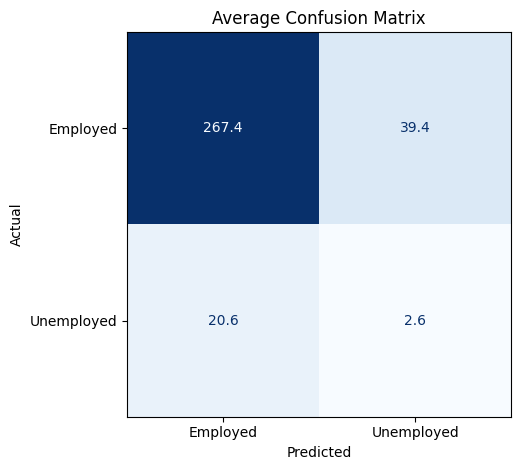

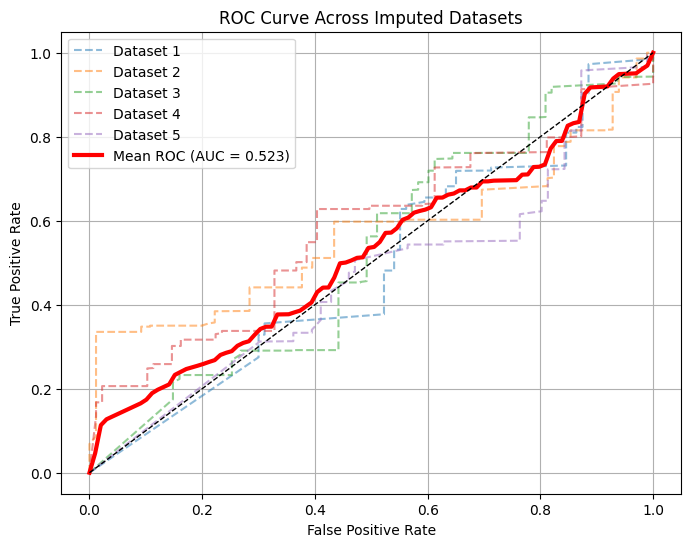


===== AVERAGE PERMUTATION IMPORTANCE =====
PAR2GRD_3    -0.005121
BEF_160_5    -0.009333
BEF_160_4    -0.010424
BEF_160_1    -0.013424
BEF_160_3    -0.013758
PGM_P100_1   -0.019970
PAR2GRD_2    -0.020485
PGM_P100_2   -0.021515
PAR1GRD_2    -0.022091
BEF_160_2    -0.023636
PAR2GRD_1    -0.025364
PAR1GRD_3    -0.026273
EDU_010_1    -0.030424
EDU_010_2    -0.031818
PAR1GRD_1    -0.032727
PGM_350_2    -0.040758
PGM_350_1    -0.041303
STULOANS_2   -0.042545
STULOANS_1   -0.043576
BEF_160_6    -0.049030
dtype: float64


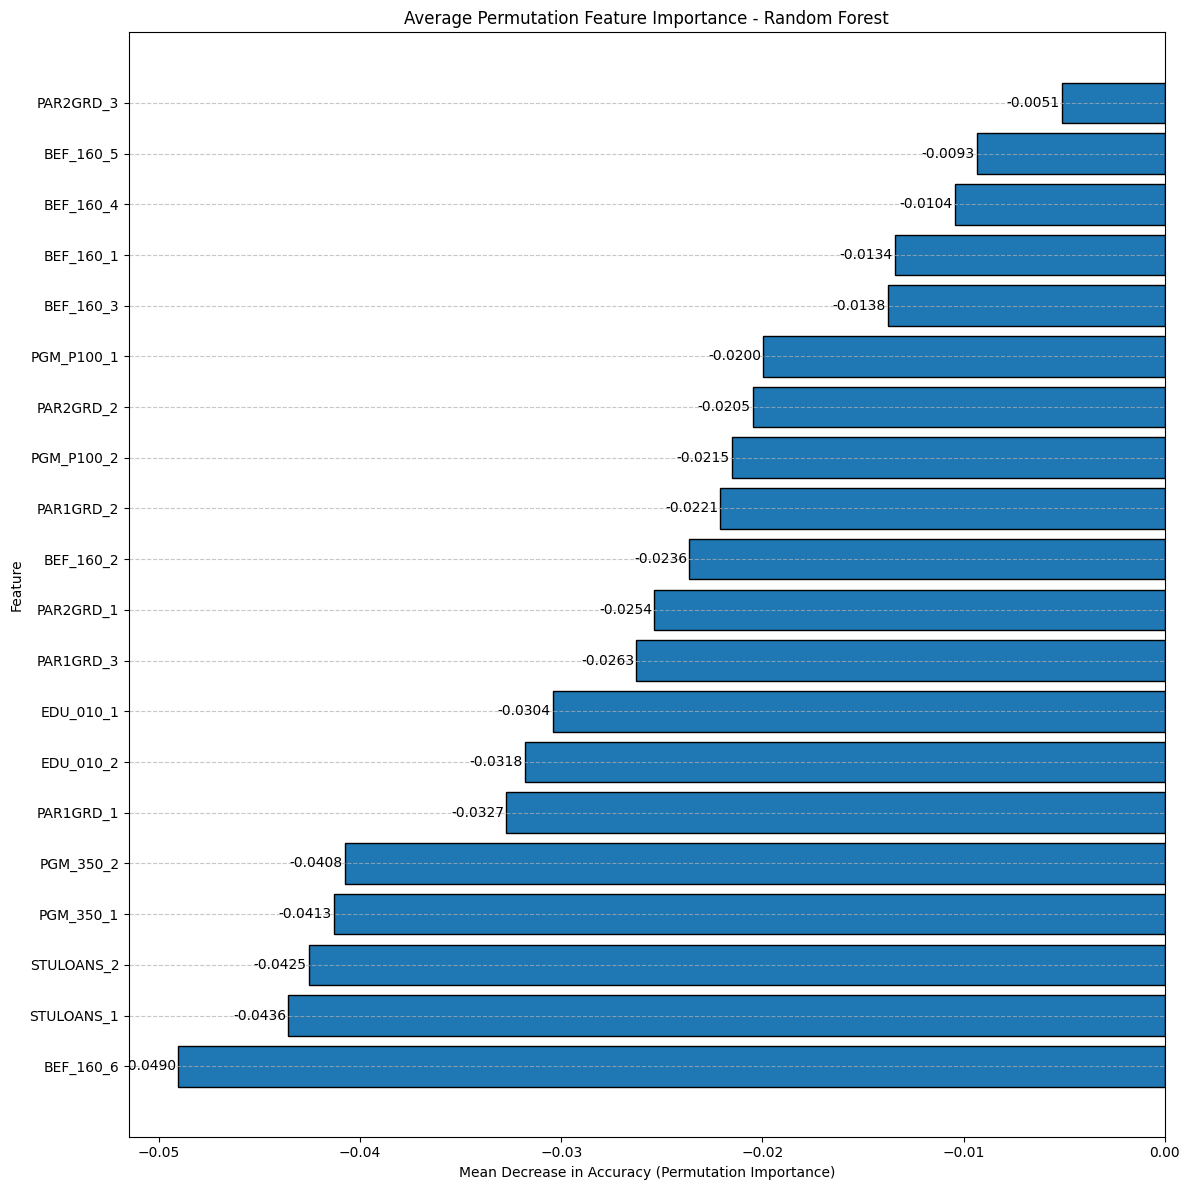

In [ ]:
# -----------------------------
# AVERAGED METRICS
# -----------------------------
metrics_df = pd.DataFrame(metrics_list)
print("\n===== AVERAGED METRICS (Test) =====")
print(metrics_df.mean())

# -----------------------------
# AVERAGED CONFUSION MATRIX
# -----------------------------
avg_cm = np.mean(conf_matrices, axis=0)

print("\n===== AVERAGE CONFUSION MATRIX (Test) =====")
print(pd.DataFrame(
    avg_cm,
    index=["Actual 1", "Actual 2"],
    columns=["Predicted 1", "Predicted 2"]
))

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Define label mapping
labels = [1, 2]
display_labels = ["Employed", "Unemployed"]

# Plot
plt.figure(figsize=(12, 5))

# Test
disp_test = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=display_labels)
disp_test.plot( cmap='Blues', colorbar=False, values_format='.1f')
plt.title("Average Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# -----------------------------
# ROC CURVE
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

plt.figure(figsize=(8,6))

for i, (y_test, y_prob, w_test) in enumerate(roc_data):
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1, sample_weight=w_test)
    plt.plot(fpr, tpr, linestyle='--', alpha=0.5, label=f"Dataset {i+1}")

    # Interpolate tpr to align with mean_fpr
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0  # Ensure it starts at 0
    tprs.append(interp_tpr)
    aucs.append(auc(fpr, tpr))

# Now tprs is a list of arrays, all length 100
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0  # Ensure it ends at 1
mean_auc = np.mean(aucs)

# Plot the mean ROC
plt.plot(mean_fpr, mean_tpr, color='red', lw=3, label=f"Mean ROC (AUC = {mean_auc:.3f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--', color='black', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Across Imputed Datasets")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# AVERAGE PERMUTATION IMPORTANCE
# -----------------------------
import matplotlib.pyplot as plt
import pandas as pd

# Combine permutation importance results and compute mean
perm_df = pd.concat(perm_importances_list, axis=1)  # list of Series for each dataset
perm_mean = perm_df.mean(axis=1)

print("\n===== AVERAGE PERMUTATION IMPORTANCE =====")
print(perm_mean.sort_values(ascending=False))  

# Sort for plotting (top 20)
perm_mean_sorted = perm_mean.sort_values(ascending=False)[::-1]  # reverse for top-to-bottom

plt.figure(figsize=(12,12))
bars = plt.barh(
    perm_mean_sorted.index,
    perm_mean_sorted.values,
    edgecolor='black'
)

plt.xlabel("Mean Decrease in Accuracy (Permutation Importance)")
plt.ylabel("Feature")
plt.title("Average Permutation Feature Importance - Random Forest")

# Horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels outside bars regardless of sign
ax = plt.gca()
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if width >= 0:
        x_text = width + 0.0001  # positive: place to the right
        ha = 'left'
    else:
        x_text = width - 0.0001  # negative: place to the left
        ha = 'right'
    ax.text(
        x=x_text,
        y=y,
        s=f"{width:.4f}",
        va='center',
        ha=ha,
        clip_on=True
    )

plt.tight_layout()
plt.show()
